# Data cleaning & manipulation

## **Notebook Overview**

This notebook prepares the dataset for a regression model that predicts duration_difference_min.
The workflow is structured into modular functions, each handling a specific step:
Data type fixing and standardization
Missing values handling
Outlier correction and filtering
Feature engineering
Categorical encoding
After preprocessing, irrelevant and leakage-prone columns are removed.
Feature selection is performed using multiple regression-based methods, and results are combined into a summary table.
Finally, XGBoost models are trained on different feature subsets and compared using RMSE, MAE, and R².

## Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
#from src.data_cleaning_and_manipulations import impute_by_agency_line_hour
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Functions

In [15]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


def fix_data_types(df):
    """Fix all column types and rename columns"""
    
    for col in df.select_dtypes(include=["datetime"]).columns:
        df[col] = df[col].dt.strftime("%Y-%m-%d %H:%M:%S")
    
    # Hour
    if 'hour_rounded' in df.columns:
        df = df.rename(columns={'hour_rounded': 'full_hour'})
    
    # Day - categorical with order
    day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    df['day'] = pd.Categorical(df['day'], categories=day_order, ordered=True)
    
    # String columns
    str_cols = ['line_name', 'alternative', 'agency_name', 'origin_city', 
                'origin_station', 'destination_city', 'destination_station', 'route_type']
    df[str_cols] = df[str_cols].astype(str)
    df['route_type'] = df['route_type'].str.strip()

    return df


def handle_missing_values(df, ref_df=None, printing_missing_values=False):
    """
    Handle missing values.
    ref_df = Train df (for calculating medians/means)
    If ref_df=None, uses df itself (for train only)
    """
    if ref_df is None:
        ref_df = df

    if printing_missing_values:
        print("Missing values BEFORE handling:")
        print(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))
        print("-" * 50)

    # Convert day to string for groupby
    df['day'] = df['day'].astype(str)

    # Total_Passengers - progressive groupby imputation
    for col in ['Total_Passengers']:
        df[col] = df.groupby(['route_id', 'direction', 'day', 'full_hour'])[col].transform(
            lambda x: x.fillna(x.median())
        )
        df[col] = df.groupby(['route_id', 'direction', 'day'])[col].transform(
            lambda x: x.fillna(x.median())
        )
        df[col] = df.groupby(['route_id'])[col].transform(
            lambda x: x.fillna(x.median())
        )
        df[col] = df[col].fillna(ref_df[col].median())

    # Avg_Passengers_Per_Bus
    df['Avg_Passengers_Per_Bus'] = df.groupby('route_id')['Avg_Passengers_Per_Bus'].transform(
        lambda x: x.fillna(x.median())
    )
    df['Avg_Passengers_Per_Bus'] = df['Avg_Passengers_Per_Bus'].fillna(
        ref_df['Avg_Passengers_Per_Bus'].median()
    )

    # circular_route
    df['circular_route'] = df['circular_route'].fillna(0)

    # Text columns
    df["line_name"] = df["line_name"].fillna("unknown")
    df["agency_name"] = df["agency_name"].fillna("unknown")
    df["line_num"] = df["line_num"].fillna("unknown")

    # Speed and duration-related columns
    for col in ['speed_kmh_actual', 'duration_min_actual', 'duration_difference_min']:
        df[col] = df.groupby(['route_id', 'direction'])[col].transform(
            lambda x: x.fillna(x.median())
        )
        df[col] = df[col].fillna(ref_df[col].median())

    # Geometric columns
    geo_cols = ['curvity', 'route_length', 'length_in_buffer_m']
    for col in geo_cols:
        if col in df.columns:
            df[col] = df[col].fillna(ref_df[col].mean())

    # Fix route_length zeros/NaNs using route_length_km
    if 'route_length' in df.columns and 'route_length_km' in df.columns:
        zero_mask = (df['route_length'] == 0) | (df['route_length'].isna())
        df.loc[zero_mask, 'route_length'] = df.loc[zero_mask, 'route_length_km'] * 1000

    if printing_missing_values:
        print("Missing values AFTER handling:")
        print(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))
        print("-" * 50)

    return df


def handle_outliers(df, boxplots=False, boxplot_cols=None, verbose=False):
    """
    Handle outliers:
    - Fix speed_kmh_planned > 100
    - Fix trips ending after midnight
    - Remove rows where duration_difference_min > 120 or < -120
    """
    if boxplot_cols is None:
        boxplot_cols = [
            'full_hour', 'route_length_km', 'number_of_stops', 'rainfall_mm',
            'Total_Passengers', 'curvity', 'duration_min_planned',
            'duration_min_actual', 'speed_kmh_planned', 'speed_kmh_actual',
            'duration_difference_min'
        ]

    boxplot_cols = [col for col in boxplot_cols if col in df.columns]

    if boxplots:
        print("\nBoxplots BEFORE outlier handling:")
        plot_boxplots_with_outliers(df, boxplot_cols)

    # Fix speed > 100
    mask_high = df['speed_kmh_planned'] > 100
    if verbose:
        print(f"Rows with speed > 100: {mask_high.sum()}")
    df.loc[mask_high, 'speed_kmh_planned'] = df.loc[mask_high, 'speed_kmh_planned'] / 1000

    # Fix trips ending after midnight
    df['departure_time_planned'] = pd.to_datetime(df['departure_time_planned'].astype(str), format='mixed')
    df['arrival_time_planned'] = pd.to_datetime(df['arrival_time_planned'].astype(str), format='mixed')

    mask_midnight = df['arrival_time_planned'] < df['departure_time_planned']
    if verbose:
        print(f"Trips ending after midnight: {mask_midnight.sum()}")

    df.loc[mask_midnight, 'duration_min_planned'] = (
        (df.loc[mask_midnight, 'arrival_time_planned'] + pd.Timedelta(days=1)) -
        df.loc[mask_midnight, 'departure_time_planned']
    ).dt.total_seconds() / 60

    df.loc[mask_midnight, 'speed_kmh_planned'] = (
        (df.loc[mask_midnight, 'route_length'] / 1000) /
        (df.loc[mask_midnight, 'duration_min_planned'] / 60)
    )

    # Remove duration_difference_min outliers
    before = len(df)
    df = df[
        (df['duration_difference_min'] >= -120) &
        (df['duration_difference_min'] <= 120)
    ].copy()
    after = len(df)

    if verbose:
        print(f"Rows removed: {before - after:,} ({(before - after)/before*100:.2f}%)")
        print(f"Rows remaining: {after:,}")

    if boxplots:
        print("\nBoxplots AFTER outlier handling:")
        plot_boxplots_with_outliers(df, boxplot_cols)

    return df


def create_target(df):
    """
    Create classification target based on duration_difference_min:
    - early:   < -10 min
    - on_time: between -10 and 10 min
    - delay:   >= 10 min
    """
    conditions = [
        df['duration_difference_min'] < -10,
        df['duration_difference_min'] >= 10
    ]
    choices = ['early', 'delay']
    df['target'] = np.select(conditions, choices, default='on_time')
    return df


def add_features(df, early_rate_map=None):
    """
    Add new features.
    early_rate_map: dict of route_id -> early_rate (from train only)
    """
    df_copy = df.copy()
    peak_hours = [7, 8, 9, 14, 15, 16, 17]

    # Peak hour flag
    df_copy['is_peak_hour'] = df_copy['full_hour'].isin(peak_hours).astype(int)

    # Urban flag
    df_copy['urban'] = (df_copy['route_length'] <= 25000).astype(int)

    # Perc within PT route
    df_copy['perc_within_pt_route'] = np.where(
        df_copy['route_length'] > 0,
        df_copy['length_in_buffer_m'] / df_copy['route_length'],
        np.nan
    )
    df_copy['perc_within_pt_route'] = df_copy['perc_within_pt_route'].replace(
        [np.inf, -np.inf], np.nan
    ).fillna(0).clip(0, 2)

    # Peak weighted perc
    df_copy['perc_within_pt_route_peak'] = df_copy['perc_within_pt_route'] * df_copy['is_peak_hour']

    # Interaction features
    df_copy['passengers_x_peak'] = df_copy['Total_Passengers'] * df_copy['is_peak_hour']
    df_copy['stops_x_passengers'] = df_copy['number_of_stops'] * df_copy['Total_Passengers']

    # Arrival and departure hour
    df_copy['departure_hour'] = pd.to_datetime(
        df_copy['departure_time_planned'], format='mixed'
    ).dt.hour
    df_copy['arrival_hour'] = pd.to_datetime(
        df_copy['arrival_time_planned'], format='mixed'
    ).dt.hour

    # Combined categorical feature
    df_copy['agency_linenum_dir_alter'] = (
        df_copy['agency_name'].astype(str) +
        df_copy['line_num'].astype(str) +
        df_copy['direction'].astype(str) +
        df_copy['alternative'].astype(str)
    )

    # Time of Day
    def get_time_of_day(hour):
        if hour <= 5:    return 'night'
        elif hour <= 9:  return 'morning'
        elif hour <= 14: return 'midday'
        elif hour <= 18: return 'afternoon'
        else:            return 'evening'

    df_copy['time_of_day'] = df_copy['full_hour'].apply(get_time_of_day)

    # Route length category
    df_copy['route_length_cat'] = pd.qcut(
        df_copy['route_length_km'], q=3, labels=['short', 'mid', 'long']
    )

    # Is night
    df_copy['is_night'] = df_copy['full_hour'].isin([0,1,2,3,4,5]).astype(int)

    # Night x long route
    df_copy['night_x_long_route'] = df_copy['is_night'] * df_copy['route_length_km']

    # Historical early rate per route (from train only)
    if early_rate_map is not None:
        df_copy['route_early_rate'] = df_copy['route_id'].map(early_rate_map)
        df_copy['route_early_rate'] = df_copy['route_early_rate'].fillna(
            df_copy['route_early_rate'].median()
        )

    return df_copy


def encode_categorical_columns(df, te=None, alternative_cols=None):
    """
    Encode categorical columns.
    te = TargetEncoder fitted object (fit on train only)
    """
    from category_encoders import TargetEncoder

    # Remove duplicates
    df = df.loc[:, ~df.columns.duplicated()]

    # Ordinal encoding - day
    day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    day_mapping = {day: i for i, day in enumerate(day_order)}
    df['day_encoded'] = df['day'].map(day_mapping)

    # Target encoding - using duration_difference_min as numeric target
    target_cols = ['agency_name', 'origin_city', 'destination_city',
                   'origin_station', 'destination_station', 'agency_linenum_dir_alter']

    if te is None:
        te = TargetEncoder()
        df[[f'{col}_encoded' for col in target_cols]] = te.fit_transform(
            df[target_cols], df['duration_difference_min']
        )
    else:
        df[[f'{col}_encoded' for col in target_cols]] = te.transform(df[target_cols])

    # Encode time_of_day and route_length_cat
    tod_mapping = {'night': 0, 'morning': 1, 'midday': 2, 'afternoon': 3, 'evening': 4}
    if 'time_of_day' in df.columns:
        df['time_of_day_encoded'] = df['time_of_day'].map(tod_mapping)

    rlc_mapping = {'short': 0, 'mid': 1, 'long': 2}
    if 'route_length_cat' in df.columns:
        df['route_length_cat_encoded'] = df['route_length_cat'].map(rlc_mapping).astype(int)

    # Remove duplicates
    df = df.loc[:, ~df.columns.duplicated()]

    return df, te, alternative_cols


def plot_boxplots_with_outliers(df, cols, n_cols=2, figsize=(20, 24)):
    """Plot boxplots with outlier statistics"""
    n_rows = math.ceil(len(cols) / n_cols)
    plt.figure(figsize=figsize)

    for i, col in enumerate(cols):
        ax = plt.subplot(n_rows, n_cols, i + 1)
        sns.boxplot(data=df, x=col, ax=ax, color='navy')

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        n_outliers = len(df[(df[col] < lower) | (df[col] > upper)])
        pct_outliers = (n_outliers / len(df)) * 100

        ax.set_title(f'{col}\nOutliers: {n_outliers:,} ({pct_outliers:.1f}%)', fontsize=11)
        ax.set_xlabel(col)

    plt.subplots_adjust(hspace=0.5, wspace=0.3)
    plt.tight_layout()
    plt.show()


def drop_unnecessary_columns(df):
    """Drop columns that are already encoded, not relevant, or cause data leakage"""
    cols_to_drop = [
        # Already encoded
        'day', 'alternative', 'agency_name', 'origin_city',
        'origin_station', 'destination_city', 'destination_station',
        'time_of_day', 'route_length_cat',
        # Identical to other columns
        'route_mkt',
        # Text/time
        'date', 'line_name', 'departure_time_planned',
        'arrival_time_planned', 'route_type', 'line_num', 'agency_linenum_dir_alter',
        # Data Leakage
        'duration_min_actual', 'duration_min_planned', 'speed_kmh_actual',
    ]
    df = df.drop(columns=cols_to_drop, errors='ignore')
    return df


def run_feature_selection_methods(X_train, y_train):
    """
    Run multiple feature selection methods for classification.
    Returns selection_df with selected/not selected features per method.
    """
    from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler

    methods = ["RandomForest", "GradientBoost", "LogisticRegression"]
    print("Feature selection methods:")
    for i, m in enumerate(methods, 1):
        print(f"{i}. {m}")
    print("-" * 50)

    finished = 0

    # 1. Random Forest
    rf = RandomForestClassifier(random_state=42, class_weight='balanced').fit(X_train, y_train)
    rf_selected = (rf.feature_importances_ > 0).astype(int)
    finished += 1
    print(f"Finished RandomForest ({finished}/{len(methods)})")

    # 2. Gradient Boosting
    gb = GradientBoostingClassifier(random_state=42).fit(X_train, y_train)
    gb_selected = (gb.feature_importances_ > 0).astype(int)
    finished += 1
    print(f"Finished GradientBoost ({finished}/{len(methods)})")

    # 3. Logistic Regression
    lr = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    )
    lr.fit(X_train, y_train)
    lr_coef = np.abs(lr.named_steps['logisticregression'].coef_).max(axis=0)
    lr_selected = (lr_coef > 0).astype(int)
    finished += 1
    print(f"Finished LogisticRegression ({finished}/{len(methods)})")

    selection_df = pd.DataFrame({
        "Feature": X_train.columns,
        "RandomForest": rf_selected,
        "GradientBoost": gb_selected,
        "LogisticRegression": lr_selected
    })

    selection_cols = ["RandomForest", "GradientBoost", "LogisticRegression"]
    selection_df["Sum"] = selection_df[selection_cols].sum(axis=1)
    selection_df = selection_df.sort_values(by="Sum", ascending=False).reset_index(drop=True)

    return selection_df


def manipulate_df_process(df, ref_df=None, te=None, early_rate_map=None):
    """
    Full pipeline for train/val/test processing.
    ref_df: train df (for missing value imputation)
    te: fitted TargetEncoder (None for train)
    early_rate_map: dict of route_id -> early_rate (from train only)
    """
    df = fix_data_types(df)
    df = handle_missing_values(df, ref_df=ref_df)
    df = handle_outliers(df)
    df = create_target(df)
    df = add_features(df, early_rate_map=early_rate_map)
    df, te, _ = encode_categorical_columns(df, te=te)
    return df, te


def compare_xgb_feature_sets(X_train, y_train, X_val, y_val, selection_df):
    """
    Compare XGBoost classification performance on different feature sets.
    Sorted by F1 of delay and early classes (most important).
    """
    from xgboost import XGBClassifier
    from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report
    from sklearn.preprocessing import LabelEncoder

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_val_enc = le.transform(y_val)

    # Find class indices
    classes = list(le.classes_)
    delay_idx = classes.index('delay') if 'delay' in classes else None
    early_idx = classes.index('early') if 'early' in classes else None

    results = []

    feature_sets = {
        "All Features": X_train.columns.tolist(),
        "Sum == 3": selection_df.loc[selection_df["Sum"] == 3, "Feature"].tolist(),
        "Sum >= 2": selection_df.loc[selection_df["Sum"] >= 2, "Feature"].tolist()
    }

    print("Running XGBoost on feature sets:")
    for name, feats in feature_sets.items():
        print(f"- {name}: {len(feats)} features")
    print("-" * 50)

    for name, feats in feature_sets.items():
        if len(feats) == 0:
            print(f"Skipping {name} (no features)")
            continue

        model = XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric='mlogloss'
        )
        model.fit(X_train[feats], y_train_enc)
        y_pred = model.predict(X_val[feats])

        acc    = accuracy_score(y_val_enc, y_pred)
        f1_mac = f1_score(y_val_enc, y_pred, average='macro')

        f1_per_class     = f1_score(y_val_enc, y_pred, average=None)
        recall_per_class = recall_score(y_val_enc, y_pred, average=None)

        f1_delay  = f1_per_class[delay_idx]  if delay_idx is not None else None
        f1_early  = f1_per_class[early_idx]  if early_idx is not None else None
        rec_delay = recall_per_class[delay_idx] if delay_idx is not None else None
        rec_early = recall_per_class[early_idx] if early_idx is not None else None
        f1_delay_early = (f1_delay + f1_early) / 2

        print(f"\n{name}:")
        print(f"  Accuracy:       {acc:.3f}")
        print(f"  F1 Macro:       {f1_mac:.3f}")
        print(f"  F1 Delay:       {f1_delay:.3f}")
        print(f"  F1 Early:       {f1_early:.3f}")
        print(f"  Recall Delay:   {rec_delay:.3f}")
        print(f"  Recall Early:   {rec_early:.3f}")
        print(f"  F1 Delay+Early: {f1_delay_early:.3f}")
        print(classification_report(y_val_enc, y_pred, target_names=le.classes_))

        results.append({
            "Feature_Set":    name,
            "Num_Features":   len(feats),
            "Accuracy":       acc,
            "F1_Macro":       f1_mac,
            "F1_Delay":       f1_delay,
            "F1_Early":       f1_early,
            "Recall_Delay":   rec_delay,
            "Recall_Early":   rec_early,
            "F1_Delay_Early": f1_delay_early
        })

    return pd.DataFrame(results).sort_values(by="F1_Delay_Early", ascending=False)

## Imports

In [3]:
train_df = pd.read_csv(r'../data/model_datasets/train_df.csv', encoding='utf-8-sig')
print(f"Train:      {len(train_df):,} rows")

Train:      63,616 rows


In [4]:
train_df.columns

Index(['date', 'day', 'full_hour', 'line_num', 'line_name', 'route_id',
       'route_mkt', 'direction', 'alternative', 'agency_name', 'route_type',
       'origin_city', 'origin_station', 'destination_city',
       'destination_station', 'number_of_stops', 'route_length_km',
       'departure_time_planned', 'arrival_time_planned',
       'duration_min_planned', 'duration_min_actual',
       'duration_difference_min', 'speed_kmh_planned', 'speed_kmh_actual',
       'rainfall_mm', 'length_in_buffer_m', 'route_length', 'curvity',
       'circular_route', 'Total_Passengers', 'Avg_Passengers_Per_Bus',
       'target'],
      dtype='object')

## 1. Manage Data types

**Step 1: Fix data types and standardize columns**
- Convert datetime columns to string format
- Rename 'hour_rounded' to 'full_hour' for consistency
- Convert 'day' to an ordered categorical variable (Sunday → Saturday)
- Ensure key categorical columns are treated as strings
- Clean text fields (e.g., remove whitespace from 'route_type')

In [5]:
# Run
train_df = fix_data_types(train_df)
print(train_df.dtypes)

date                         object
day                        category
full_hour                     int64
line_num                     object
line_name                    object
route_id                      int64
route_mkt                     int64
direction                     int64
alternative                  object
agency_name                  object
route_type                   object
origin_city                  object
origin_station               object
destination_city             object
destination_station          object
number_of_stops               int64
route_length_km             float64
departure_time_planned       object
arrival_time_planned         object
duration_min_planned        float64
duration_min_actual         float64
duration_difference_min     float64
speed_kmh_planned           float64
speed_kmh_actual            float64
rainfall_mm                 float64
length_in_buffer_m          float64
route_length                float64
curvity                     

## 2. Missing values handling

**Handle Missing Values**

- Impute missing values using hierarchical group-based strategies (from granular to general levels)
- Apply fallback imputation using global statistics from a reference dataset (train set)
- Handle categorical missing values by assigning default labels (e.g., "unknown")
- Fill binary/indicator features with default values where appropriate
- Ensure consistency in numerical features using group-level and global aggregations
- Correct invalid or inconsistent values (e.g., zero or missing lengths)
- Optionally print missing values summary before and after processing

In [6]:
train_df = handle_missing_values(train_df, printing_missing_values=True)

Missing values BEFORE handling:
Total_Passengers           813
Avg_Passengers_Per_Bus     813
length_in_buffer_m         119
curvity                    119
circular_route             119
duration_min_actual         89
duration_difference_min     89
speed_kmh_actual            89
route_length                 4
dtype: int64
--------------------------------------------------
Missing values AFTER handling:
Series([], dtype: int64)
--------------------------------------------------


## 3. Outliers handling

**Handle Outliers**

- Identify and correct unrealistic values in key features
- Adjust planned trips that cross midnight by recalculating duration and speed
- Remove extreme values in the target variable based on defined thresholds
- Report number and proportion of removed observations
- Optionally visualize feature distributions before and after outlier handling using boxplots

In [7]:
train_df = handle_outliers(train_df, boxplots=False, verbose=True)

Rows with speed > 100: 0
Trips ending after midnight: 1040
Rows removed: 251 (0.39%)
Rows remaining: 63,365


## 4. Create Target

In [8]:
train_df = create_target(train_df)
print(train_df['target'].value_counts())

target
delay      44696
on_time    15277
early       3392
Name: count, dtype: int64


## 5. Add Features

**Add Features**

- Create peak-hour indicator based on predefined morning and afternoon peak periods
- Create urban/interurban indicator based on route length
- Calculate the share of the route located within the public transport buffer
- Create peak-weighted route-buffer feature
- Add interaction features between passengers, stops, and peak-hour conditions
- Extract planned departure and arrival hour features
- Create combined categorical route identifier using agency, line, direction, and alternative values

In [9]:
train_df = add_features(train_df)
print(f"Shape after features: {train_df.shape}")

Shape after features: (63365, 45)


## 6. Categorical Data Handling

**Encode Categorical Columns**

- Remove duplicate columns before and after the encoding process
- Convert day into an ordinal numerical feature based on weekday order
- Apply target encoding to high-cardinality categorical features
- Fit the target encoder on the training dataset only
- Apply the same encoder to validation and test datasets to avoid data leakage
- Return the transformed dataset along with the fitted encoder for reuse

In [10]:
train_df, te, alternative_cols = encode_categorical_columns(train_df, te=None, alternative_cols=None)
print(f"Shape after encoding: {train_df.shape}")

Shape after encoding: (63365, 54)


## 7. Feature Selection

**Feature Selection Process** 

-  Drop columns that are not suitable for modeling:
    - Original categorical columns that were already encoded
    - Raw text and datetime columns that cannot be used directly by the model
    - Duplicate or redundant columns
    - Data leakage columns, such as actual duration and actual speed, that directly reveal  information related to the target
- Define the target variable: duration_difference_min
- Create X_train and y_train after removing the target column
- Run several feature selection methods for a regression problem:
    - Random Forest feature importance
    - Gradient Boosting feature importance
    - Lasso coefficient selection
    - Linear SVR coefficient selection
    - Ridge coefficient ranking
-  Store the result of each method in a feature-selection summary table
-  Calculate a final Sum score for each feature, based on how many methods selected it
-  Compare XGBoost model performance using different feature sets:
    - All available features
    - Features selected by all methods (Sum == 5)
    - Features selected by at least four methods (Sum >= 4)
-  Evaluate and compare the results using RMSE, MAE, and R².

In [11]:
train_df = drop_unnecessary_columns(train_df)

# Define X and y
cols_to_exclude = ['target', 'duration_difference_min']
X_train = train_df.drop(columns=cols_to_exclude, errors='ignore')
y_train = train_df['target']

print(f"X_train shape: {X_train.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")

# Run feature selection
selection_df = run_feature_selection_methods(X_train, y_train)
selection_df

X_train shape: (63365, 32)
y_train distribution:
target
delay      44696
on_time    15277
early       3392
Name: count, dtype: int64
Feature selection methods:
1. RandomForest
2. GradientBoost
3. LogisticRegression
--------------------------------------------------
Finished RandomForest (1/3)
Finished GradientBoost (2/3)
Finished LogisticRegression (3/3)


,Feature,RandomForest,GradientBoost,LogisticRegression,Sum
0,full_hour,1,1,1,3
1,route_id,1,1,1,3
2,time_of_day_encoded,1,1,1,3
3,agency_linenum_dir_alter_encoded,1,1,1,3
4,destination_station_encoded,1,1,1,3
5,origin_station_encoded,1,1,1,3
6,destination_city_encoded,1,1,1,3
7,origin_city_encoded,1,1,1,3
8,agency_name_encoded,1,1,1,3
9,day_encoded,1,1,1,3


## 8. Manipulation Pipeline (Val + Test)

In [12]:
val_df   = pd.read_csv(r'../data/model_datasets/val_df.csv', encoding='utf-8-sig')
test_df  = pd.read_csv(r'../data/model_datasets/test_df.csv', encoding='utf-8-sig')

# חשב early_rate_map מהטריין בלבד
early_rate_map = train_df.groupby('route_id')['target'].apply(
    lambda x: (x == 'early').mean()
).to_dict()

# Val
print("=== Processing Validation ===")
val_df, _ = manipulate_df_process(val_df, ref_df=train_df, te=te, early_rate_map=early_rate_map)
val_df = drop_unnecessary_columns(val_df)

# Test
print("=== Processing Test ===")
test_df, _ = manipulate_df_process(test_df, ref_df=train_df, te=te, early_rate_map=early_rate_map)
test_df = drop_unnecessary_columns(test_df)

print(f"\nTrain:      {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test:       {test_df.shape}")

=== Processing Validation ===
=== Processing Test ===

Train:      (63365, 34)
Validation: (13563, 35)
Test:       (13588, 35)


## 9. Compare XGBoost Feature Sets

In [17]:
cols_to_exclude = ['target', 'duration_difference_min']
X_val = val_df.drop(columns=cols_to_exclude, errors='ignore')
y_val = val_df['target']

# המר כל עמודות category ל-int
for col in X_train.select_dtypes(include='category').columns:
    X_train[col] = X_train[col].astype(int)

for col in X_val.select_dtypes(include='category').columns:
    X_val[col] = X_val[col].astype(int)

results_df = compare_xgb_feature_sets(X_train, y_train, X_val, y_val, selection_df)
results_df

Running XGBoost on feature sets:
- All Features: 32 features
- Sum == 3: 27 features
- Sum >= 2: 32 features
--------------------------------------------------

All Features:
  Accuracy:       0.832
  F1 Macro:       0.683
  F1 Delay:       0.899
  F1 Early:       0.466
  Recall Delay:   0.928
  Recall Early:   0.349
  F1 Delay+Early: 0.683
              precision    recall  f1-score   support

       delay       0.87      0.93      0.90      9572
       early       0.70      0.35      0.47       740
     on_time       0.71      0.66      0.68      3251

    accuracy                           0.83     13563
   macro avg       0.76      0.65      0.68     13563
weighted avg       0.82      0.83      0.82     13563


Sum == 3:
  Accuracy:       0.832
  F1 Macro:       0.685
  F1 Delay:       0.900
  F1 Early:       0.469
  Recall Delay:   0.929
  Recall Early:   0.351
  F1 Delay+Early: 0.684
              precision    recall  f1-score   support

       delay       0.87      0.93      0.9

,Feature_Set,Num_Features,Accuracy,F1_Macro,F1_Delay,F1_Early,Recall_Delay,Recall_Early,F1_Delay_Early
1,Sum == 3,27,0.832485,0.684516,0.899661,0.469314,0.928751,0.351351,0.684488
2,Sum >= 2,32,0.832485,0.684315,0.899585,0.468047,0.928437,0.351351,0.683816
0,All Features,32,0.831969,0.683059,0.899337,0.465704,0.928228,0.348649,0.682520


In [18]:
# בחר את קבוצת הפיצ'רים הטובה ביותר
best_features = selection_df.loc[selection_df["Sum"] == 3, "Feature"].tolist()

print(f"Number of selected features: {len(best_features)}")
print(f"Features: {best_features}")

# עדכן את X_train ו-X_val
X_train = X_train[best_features]
X_val   = X_val[best_features]

# עדכן גם את X_test
cols_to_exclude = ['target', 'duration_difference_min']
X_test = test_df.drop(columns=cols_to_exclude, errors='ignore')
for col in X_test.select_dtypes(include='category').columns:
    X_test[col] = X_test[col].astype(int)
X_test  = X_test[best_features]
y_test  = test_df['target']

print(f"\nX_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

Number of selected features: 27
Features: ['full_hour', 'route_id', 'time_of_day_encoded', 'agency_linenum_dir_alter_encoded', 'destination_station_encoded', 'origin_station_encoded', 'destination_city_encoded', 'origin_city_encoded', 'agency_name_encoded', 'day_encoded', 'night_x_long_route', 'is_night', 'arrival_hour', 'departure_hour', 'stops_x_passengers', 'passengers_x_peak', 'perc_within_pt_route_peak', 'perc_within_pt_route', 'Avg_Passengers_Per_Bus', 'Total_Passengers', 'curvity', 'route_length', 'length_in_buffer_m', 'rainfall_mm', 'speed_kmh_planned', 'route_length_km', 'number_of_stops']

X_train: (63365, 27)
X_val:   (13563, 27)
X_test:  (13588, 27)


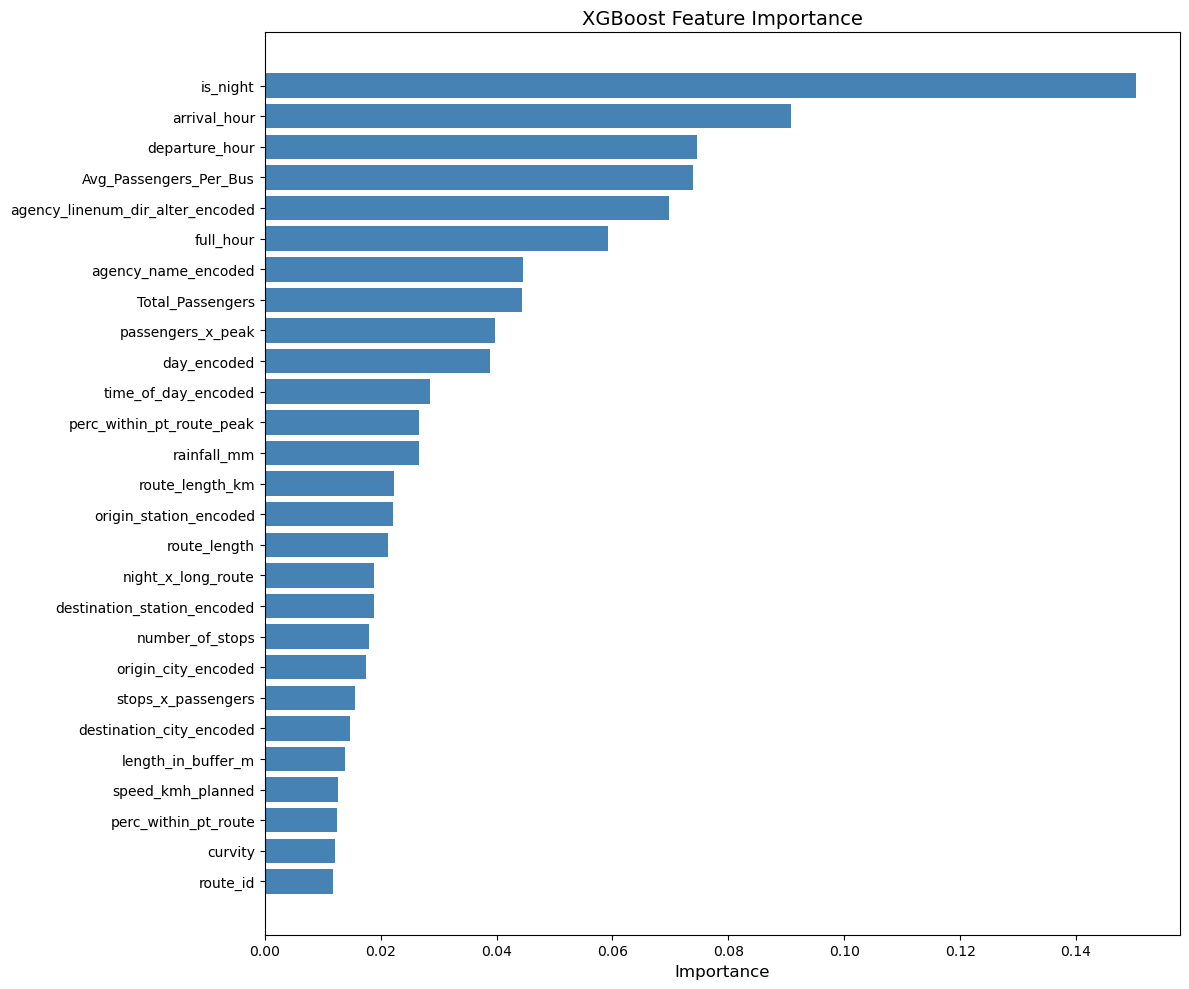

In [19]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

# אמן מודל על הפיצ'רים הנבחרים
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)
model.fit(X_train, y_train_enc)

# Feature Importance
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=True)

# גרף
plt.figure(figsize=(12, 10))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.title('XGBoost Feature Importance', fontsize=14)
plt.xlabel('Importance', fontsize=12)
plt.tight_layout()
plt.show()

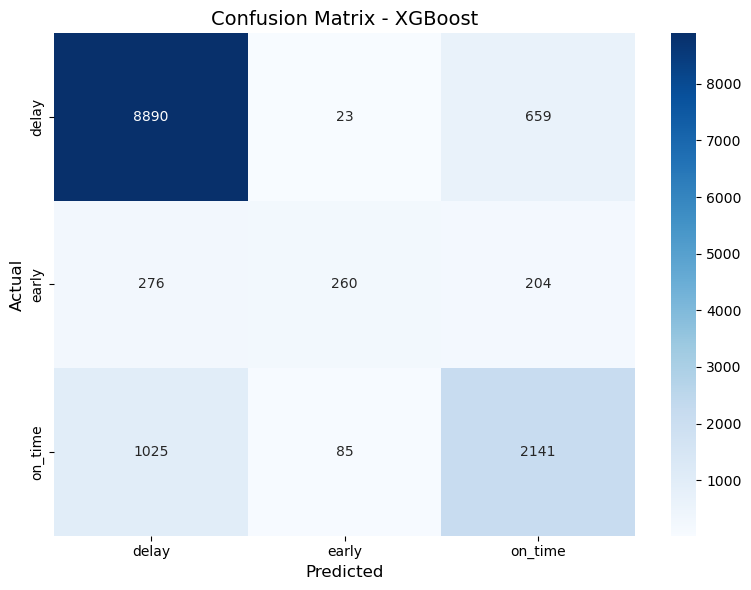

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_val_enc = le.transform(y_val)
y_pred = model.predict(X_val)

cm = confusion_matrix(y_val_enc, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - XGBoost', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Save

In [21]:
train_df.to_csv(r'../data/model_datasets/train_df_to_ml.csv', index=False, encoding='utf-8-sig')
val_df.to_csv(r'../data/model_datasets/val_df_to_ml.csv', index=False, encoding='utf-8-sig')
test_df.to_csv(r'../data/model_datasets/test_df_to_ml.csv', index=False, encoding='utf-8-sig')
print("✅ Saved!")

✅ Saved!


In [ ]:
def categorize_delay(df, col="duration_difference_min"):
    
    bins = [-np.inf, -30, -5, 5, 30, np.inf]
    labels = [
        "significant_early",
        "moderate_early",
        "on_time",
        "moderate_delay",
        "significant_delay"
    ]
    
    df["delay_category"] = pd.cut(df[col], bins=bins, labels=labels)
    
    return df

In [ ]:
train_df = categorize_delay(train_df, col="duration_difference_min")
val_df = categorize_delay(val_df, col="duration_difference_min")

In [ ]:
train_df["delay_category"].value_counts()
train_df["delay_category"].value_counts(normalize=True) * 100

In [ ]:
val_df["delay_category"].value_counts()
val_df["delay_category"].value_counts(normalize=True) * 100

In [ ]:
## Define target variable and X_train and y_train
target_col = "delay_category"
X_train = train_df.drop(columns=[target_col,'duration_difference_min'])
y_train = train_df[target_col]
X_val = val_df.drop(columns=[target_col,'duration_difference_min'])
y_val = val_df[target_col]

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,              
    min_samples_split=20,     
    min_samples_leaf=10,      
    max_features=0.7,        
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_val)

# --- Metrics ---
print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# --- Confusion Matrix ---
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=rf.classes_,
            yticklabels=rf.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Predict
y_train_pred = rf.predict(X_train)

# --- Metrics ---
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))

# --- Confusion Matrix ---
cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=rf.classes_,
            yticklabels=rf.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
X_val